# Nassau Candy Distributor — Data Cleaning & Lead Time Investigation

This notebook covers loading the raw dataset, investigating a critical data quality issue in the `Order Date` → `Ship Date` relationship, and completing cleaning steps (Canada drop, Factory join, Route columns, missing values check, export).

**Note on sequencing:** The Lead Time investigation (Sections 3–7) runs on the full raw dataset (10,194 rows) before the Canada rows are dropped in Section 8. This is intentional — the date corruption is unrelated to country — but the row count shifts from 10,194 to 9,994 partway through this notebook. This is flagged here to avoid confusion when comparing figures against the final cleaned dataset used in later phases.

# 1. importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Load the Dataset

In [2]:
# 2.1 Reading Excel file
df=pd.read_excel(r"C:\Users\kehka\Desktop\Unified Mentor\Nassau Candy Project\Nassau Candy Distributor.xlsx")

In [3]:
# 2.2 Dimensions of Dataframe(rows, columns)
df.shape

(10194, 18)

In [4]:
# 2.3 For summary of DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  str           
 7   City            10194 non-null  str           
 8   State/Province  10194 non-null  str           
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  str           
 11  Region          10194 non-null  str           
 12  Product ID      10194 non-null  str           
 13  Product Name    10194 non-null  str           
 14  Sales           10194 non-null  float64       
 15  Units        

In [5]:
# 2.4 Returns first 5 rows of DataFrames/Series
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## 3. Order Date vs Ship Date — Year Distribution Check

Checking the spread of years in each date column separately. If `Ship Date` is genuinely derived from `Order Date` plus a shipping delay, the two year ranges should roughly align.

**Finding:** `Order Date` spans only 2 years (2024–2025), while `Ship Date` spans 5 years (2026–2030) — a mismatch that's the first red flag.


In [6]:
print("Order Date — year counts:")
print(df['Order Date'].dt.year.value_counts().sort_index())

print("\nShip Date — year counts:")
print(df['Ship Date'].dt.year.value_counts().sort_index())

Order Date — year counts:
Order Date
2024    4181
2025    6013
Name: count, dtype: int64

Ship Date — year counts:
Ship Date
2026     711
2027    2089
2028    2367
2029    2899
2030    2128
Name: count, dtype: int64


## 4. Calculate Shipping Lead Time

Per the KPI definition: `Shipping Lead Time = Ship Date − Order Date` (days).

**Finding:** Raw range is ~904 to 1,642 days (2.5–4.5 years) — not realistic for shipping. Quartile spread also shows a tight cluster followed by a large jump, suggesting blended sub-groups rather than one continuous distribution.

In [7]:
df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

## 5. Histogram — Visualizing the Distribution

**Finding:** Three sharp, isolated spikes (~910, ~1275, ~1640) with empty gaps between — confirms Lead Time is not a continuous, naturally-varying metric.

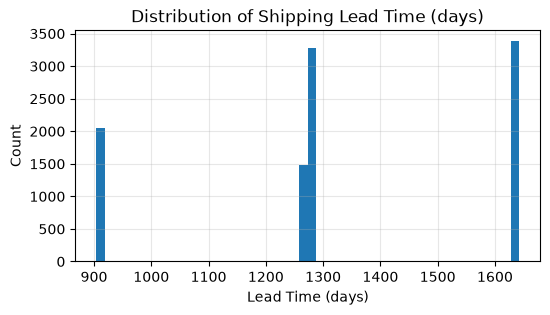

In [8]:
plt.figure(figsize=(6,3))
plt.hist(df['Lead Time'], bins=50)
plt.title("Distribution of Shipping Lead Time (days)")
plt.xlabel("Lead Time (days)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Year-Gap Analysis

Grouping by Ship year − Order year to check whether the histogram spikes correspond to distinct sub-groups.

**Finding:** Four Year Gap groups (2, 3, 4, 5). Gaps 2 and 5 are razor-tight (std dev ~1–2 days); gaps 3 and 4 are wide and overlapping (std dev ~166–181 days) — explaining why only 3 spikes appear in the histogram instead of 4.

In [9]:
df['Year Gap'] = df['Ship Date'].dt.year - df['Order Date'].dt.year

print("Year Gap value counts:")
print(df['Year Gap'].value_counts().sort_index())

print("\nLead Time stats by Year Gap:")
df.groupby('Year Gap')['Lead Time'].describe()

Year Gap value counts:
Year Gap
2     711
3    3075
4    4280
5    2128
Name: count, dtype: int64

Lead Time stats by Year Gap:


,count,mean,std,min,25%,50%,75%,max
Year Gap,,,,,,,,
2,711.0,908.195499,1.647801,904.0,907.0,908.0,909.0,912.0
3,3075.0,1113.925203,181.012824,904.0,908.0,1271.0,1273.0,1277.0
4,4280.0,1379.901402,166.328045,1269.0,1273.0,1274.0,1637.0,1642.0
5,2128.0,1638.927162,1.781389,1635.0,1638.0,1639.0,1640.0,1642.0


## 7. Year-Normalization Test

Testing whether only the Year component is corrupted, by forcing both dates to a common dummy year and re-computing the day difference.

**Finding:** Mean ≈ −55, roughly half the values negative, spread centered near zero (−193 to +182). This disproves the "only Year is corrupted" theory — Month/Day also don't preserve a real chronological relationship. The date relationship is not a simple, fixable artifact.

In [10]:
order_norm = df['Order Date'].apply(lambda x: x.replace(year=2000))
ship_norm = df['Ship Date'].apply(lambda x: x.replace(year=2000))

df['Normalized Lead Time'] = (ship_norm - order_norm).dt.days

df['Normalized Lead Time'].describe()

count    10194.000000
mean       -55.134981
std        175.705262
min       -193.000000
25%       -188.000000
50%       -186.000000
75%        177.000000
max        182.000000
Name: Normalized Lead Time, dtype: float64

## 8. Drop Canada Records

Project is scoped to a US national distributor per the Problem Statement. Dropping the 200 Canada rows (1.96% of data) to keep the dataset US-only.

**Result:** 9,994 rows remain; `Country/Region` confirmed to contain only `'United States'`.

In [11]:
df = df[df['Country/Region'] == 'United States'].copy()
df = df.reset_index(drop=True)
print(df.shape)
print(df['Country/Region'].unique())

(9994, 21)
<ArrowStringArray>
['United States']
Length: 1, dtype: str


## 9. Factory Join — Mapping Product Name to Factory

Built from `Product Name` against the Problem Statement's official mapping table — not the raw `Division` column, which was found inconsistent for Fizzy Lifting Drinks (tagged `"Sugar"` in raw data vs. `"Other"` in both the Product ID prefix and the official mapping table).

**Result:** 0 missing values — every row matched. Distribution is skewed toward Lot's O' Nuts (5,588) and Wicked Choccy's (4,060), reflecting the small number of high-volume chocolate products mapped there, not a data issue.

In [12]:
product_to_factory = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory",
}

df['Factory'] = df['Product Name'].map(product_to_factory)

In [13]:
# Sanity Check — Confirm the Join Matched Every Row
print(df['Factory'].isnull().sum())
df[df['Factory'].isnull()]['Product Name'].unique()
print(df['Factory'].value_counts())

0
Factory
Lot's O' Nuts        5588
Wicked Choccy's      4060
Secret Factory        213
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


## 10. Route Column — Factory → Customer State / Region

The Problem Statement defines a route as Factory → Customer State/Region, and requires both granularities for different dashboard modules (Region for bottleneck analysis, State for the drill-down and selector filter).

**Result:** 177 unique State-level routes, 20 unique Region-level routes (5 factories × 4 regions).

In [14]:
df['Route_State'] = df['Factory'] + " -> " + df['State/Province']
df['Route_Region'] = df['Factory'] + " -> " + df['Region']

In [15]:
# Sanity Check — Route Columns
print("Unique State-level routes:", df['Route_State'].nunique())
print("Unique Region-level routes:", df['Route_Region'].nunique())

df[['Factory', 'State/Province', 'Route_State', 'Region', 'Route_Region']].head()

Unique State-level routes: 177
Unique Region-level routes: 20


,Factory,State/Province,Route_State,Region,Route_Region
0,Wicked Choccy's,Texas,Wicked Choccy's -> Texas,Interior,Wicked Choccy's -> Interior
1,Wicked Choccy's,Illinois,Wicked Choccy's -> Illinois,Interior,Wicked Choccy's -> Interior
2,Lot's O' Nuts,Illinois,Lot's O' Nuts -> Illinois,Interior,Lot's O' Nuts -> Interior
3,Lot's O' Nuts,Illinois,Lot's O' Nuts -> Illinois,Interior,Lot's O' Nuts -> Interior
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's -> Pennsylvania,Atlantic,Wicked Choccy's -> Atlantic


## 11. Missing Values Check

**Result:** 0 missing values across all 24 columns.

In [16]:
df.isnull().sum()

Row ID                  0
Order ID                0
Order Date              0
Ship Date               0
Ship Mode               0
Customer ID             0
Country/Region          0
City                    0
State/Province          0
Postal Code             0
Division                0
Region                  0
Product ID              0
Product Name            0
Sales                   0
Units                   0
Gross Profit            0
Cost                    0
Lead Time               0
Year Gap                0
Normalized Lead Time    0
Factory                 0
Route_State             0
Route_Region            0
dtype: int64

## 12. Export Cleaned Dataset

**Result:** Exported `nassau_candy_cleaned.csv`, shape (9994, 24).

In [17]:
df.to_csv("nassau_candy_cleaned.csv", index=False)
print("Exported:", df.shape)

Exported: (9994, 24)


## Summary

**Starting point:** Raw dataset, 10,194 rows, 18 columns.

**Key investigation:** The `Order Date` → `Ship Date` relationship exhibits a systematic date anomaly and does not represent realistic shipping chronology. Therefore, raw Lead Time values are not treated as literal shipping durations in downstream analysis"(see Sections 3–7). Decision made to use Lead Time for relative ranking only, not as a literal day-count, in all downstream analysis and reporting.

**Cleaning steps completed:**
- Dropped 200 Canada records → US-only dataset (project scope)
- Joined Factory via `Product Name` (avoiding the unreliable `Division` column)
- Built `Route_State` (177 unique routes) and `Route_Region` (20 unique routes)
- Verified 0 missing values across all columns
- Exported cleaned dataset

**Final output:** `nassau_candy_cleaned.csv` — 9,994 rows, 24 columns.

**Next phase:** SQL exploratory data analysis (MySQL) using this cleaned dataset.